[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/11_LangGraph/notebooks/01_langgraph_fundamentals_and_agents.ipynb)


# LangGraph — a graph instead of a straight line

**Session 11, notebook 1.** You will run this top to bottom on your own.

## The one problem this notebook solves

Your RAG chatbot always does the same four steps, in the same order:

```
search → rerank → check → answer
```

If search is weak, it can only say "I don't know." It cannot go back and search
again. That is not a RAG problem. It is a **straight line** problem.

A **graph** can go back. That is the whole lesson.

## Three words you will reuse all day

| Word | Plain English | In code |
|---|---|---|
| **State** | A shared whiteboard | a `TypedDict` (a dictionary with named keys) |
| **Node** | One step of work | a Python function: in goes the board, out goes a small update |
| **Edge** | The arrow to the next step | `add_edge` (always) or `add_conditional_edges` (depends on the board) |

If you remember only those three, the rest of LangGraph is details.

## How to self-study this notebook

1. Run **one step**, then read **What to look at** before going on.
2. You do not need to memorize APIs. Look at the printed graph and the printed state.
3. Steps 1–4 need **no API key**. Steps 5–10 call the model.
4. "Your turn" and the experiments are optional. Skip them if you are tired.

## Roadmap

| Step | What you will see | Needs API? |
|---|---|---|
| 1 | A chain that cannot retry | no |
| 2 | Tiny graph: two boxes, one arrow | no |
| 3 | Add a loop so a missed search can try again | no |
| 4 | Why chat history must *append*, not overwrite | no |
| 5 | Same idea, now with a language model | yes |
| 6 | Branch: easy question vs hard question | yes |
| 7 | Loop until a draft is good enough | yes |
| 8 | An "agent" is a graph with tools | yes |
| 9 | Memory that survives the next question | yes |
| 10 | Watch nodes (and tokens) as they run | yes |


---
# Setup (run these two cells once)

Install packages, then load your API key. After a **fresh** install, use
**Kernel → Restart Kernel**, then run from here again.

The version pins are in quotes on purpose. Without quotes, zsh reads `>=0.6`
as a file redirect and you get `zsh: 0.6 not found`.


In [58]:
# Quotes around version pins are required on zsh.
%pip install -q "langgraph>=0.6" "langchain>=1.0" langchain-openai langchain-core python-dotenv

import importlib.metadata
print("langgraph :", importlib.metadata.version("langgraph"))
print("langchain :", importlib.metadata.version("langchain"))
print("If this was a first-time install: Kernel → Restart Kernel, then continue.")


Python(43076) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
langgraph : 1.1.3
langchain : 1.2.13
If this was a first-time install: Kernel → Restart Kernel, then continue.


Load `OPENAI_API_KEY` from a `.env` file. Jupyter's working folder is not always
this notebook's folder, so we walk upward until we find one.

We never print the key itself.


In [59]:
import warnings, os
warnings.filterwarnings("ignore")

from pathlib import Path
from dotenv import load_dotenv

here = Path.cwd().resolve()
env_files = []
for folder in [here, *here.parents]:
    for candidate in (folder / ".env", folder / "10_RAG" / ".env"):
        if candidate.is_file() and candidate not in env_files:
            env_files.append(candidate)
            load_dotenv(candidate, override=False)

print("cwd            :", here)
print("Loaded .env    :", [str(p) for p in env_files] or "NONE FOUND")
print("OPENAI_API_KEY :", "set" if os.getenv("OPENAI_API_KEY") else "MISSING — Steps 5–10 will fail")

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("Model          : gpt-4o-mini")

# Set False if you want to skip the 3-threshold writing experiment later (saves API calls).
RUN_EXPENSIVE = True


cwd            : /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/zero-to-genai-engineer/11_LangGraph/notebooks
Loaded .env    : ['/Users/mohamednoordeenalaudeen/Documents/GenAI-2026/zero-to-genai-engineer/10_RAG/.env', '/Users/mohamednoordeenalaudeen/Documents/GenAI-2026/.env']
OPENAI_API_KEY : set
Model          : gpt-4o-mini


We will draw every graph we build. Never guess what the picture looks like —
print it.


In [60]:
def show_graph(compiled):
    """Print the graph as mermaid text, and as a PNG if mermaid.ink is reachable."""
    print(compiled.get_graph().draw_mermaid())
    try:
        from IPython.display import Image, display
        display(Image(compiled.get_graph().draw_mermaid_png()))
    except Exception as e:
        print("PNG skipped (no mermaid.ink). The text diagram above is enough.", e)


---
# Step 1 of 10 — A chain that cannot retry

**In one sentence:** a chain is a fixed recipe. It cannot go back.

Pretend we have two company policies, looked up by **keyword**. If the customer's
wording does not match the keyword, search misses. A chain then has to refuse.


In [61]:
DOCS = {
    "refund": "Refunds take 5–7 business days to the original payment method.",
    "shipping": "Standard shipping is 2 business days inside the UAE.",
}


def retrieve(query: str) -> str:
    """Return a policy only if its KEY appears in the question."""
    q = query.lower()
    for key, text in DOCS.items():
        if key in q:
            return text
    return "No matching policy found."


def chain_answer(query: str) -> str:
    """Search once, then answer once. No second chance."""
    ctx = retrieve(query)
    if ctx.startswith("No matching"):
        return "I don't know."
    return f"Based on policy: {ctx}"


for q in [
    "What's the refund policy?",   # contains the word 'refund' → works
    "Can I get my money back?",    # synonym — no 'refund' → fails
    "How fast do you ship?",       # 'ship' is not the key 'shipping' → fails
]:
    print("Q:", q)
    print("   search :", retrieve(q))
    print("   chain  :", chain_answer(q))
    print()


Q: What's the refund policy?
   search : Refunds take 5–7 business days to the original payment method.
   chain  : Based on policy: Refunds take 5–7 business days to the original payment method.

Q: Can I get my money back?
   search : No matching policy found.
   chain  : I don't know.

Q: How fast do you ship?
   search : No matching policy found.
   chain  : I don't know.



**What to look at**

| Question | Search | Chain |
|---|---|---|
| "What's the refund policy?" | hit | answers |
| "Can I get my money back?" | miss | **I don't know** |
| "How fast do you ship?" | miss | **I don't know** |

A person would think: "money back means refund — search again." A chain cannot.
There is no arrow back to search. Step 3 will add that arrow. First, Step 2
shows what a graph even *is*.


---
# Step 2 of 10 — The smallest graph (no loop, no model)

**In one sentence:** a graph is boxes (nodes) connected by arrows (edges),
sharing one whiteboard (state).

We will **not** call an LLM yet. Two functions:

1. `say_hello` writes `"hello"` on the board
2. `add_world` reads the board and writes `"hello world"`

```
START → say_hello → add_world → END
```


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	say_hello(say_hello)
	add_world(add_world)
	__end__([<p>__end__</p>]):::last
	__start__ --> say_hello;
	say_hello --> add_world;
	add_world --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



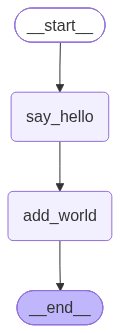

  [say_hello] board before: {'text': ''}
  [add_world]  board before: {'text': 'hello'}

Final board: {'text': 'hello world'}


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


# State = the whiteboard. Every node can read these keys and write some of them back.
class TinyState(TypedDict):
    text: str


def say_hello(state: TinyState) -> dict:
    print("  [say_hello] board before:", dict(state))
    # Return ONLY what you changed. LangGraph copies the rest forward.
    return {"text": "hello"}


def add_world(state: TinyState) -> dict:
    print("  [add_world]  board before:", dict(state))
    return {"text": state["text"] + " world"}


tiny = StateGraph(TinyState)

#NODE
tiny.add_node("say_hello", say_hello)     # name on the picture, function that runs
tiny.add_node("add_world", add_world)

#EDGE
tiny.add_edge(START, "say_hello")         # always start here
tiny.add_edge("say_hello", "add_world")   # then always go here
tiny.add_edge("add_world", END)

#COMPILE
tiny_graph = tiny.compile()               # compile = "check the picture, make it runnable"
show_graph(tiny_graph)

print("\nFinal board:", tiny_graph.invoke({"text": ""}))


**What to look at**

1. The printed picture: two boxes, arrows from START to END. That *is* the program.
2. `[say_hello]` runs first. The board starts as `{'text': ''}`.
3. `[add_world]` runs second. The board already says `hello` — even though
   `add_world` never wrote that key itself. **LangGraph merged** `say_hello`'s
   update onto the board.
4. Final board: `{'text': 'hello world'}`.

You now know how LangGraph runs. Everything else today is: more boxes, and
sometimes an arrow that goes **back**.


---
# Step 3 of 10 — Add a loop (still no model)

**In one sentence:** a conditional edge looks at the board and picks the next box.
One of those choices can be "go back."

We reuse `retrieve()` from Step 1. New idea: if search misses, **rewrite** the
question (`money back` → `refund`) and search again. Stop after 2 tries so we
cannot loop forever.

```
START → retrieve ── hit ──────────────► generate → END
              │
              ├── miss, tries left  → rewrite → retrieve   ← the new arrow
              └── miss, tries used up → give_up → END
```


In [96]:
class AskState(TypedDict):
    query: str      # current search text (rewrite may change this)
    context: str    # what search found
    answer: str     # what we show the user
    attempts: int   # how many times we have searched (safety cap)


def retrieve_node(state: AskState) -> dict:
    print(f"  [retrieve] try {state['attempts'] + 1}: {state['query']!r}")
    return {
        "context": retrieve(state["query"]),
        "attempts": state["attempts"] + 1,
    }


def rewrite_node(state: AskState) -> dict:
    q = state["query"].lower()
    if "money back" in q or "get my money" in q:
        new_q = "refund policy"
    elif "ship" in q:
        new_q = "shipping policy"
    else:
        new_q = state["query"] + " policy"
    print(f"  [rewrite]  {state['query']!r} → {new_q!r}")
    return {"query": new_q}


def generate_node(state: AskState) -> dict:
    print(f"  [generate] using {state['context']!r}")
    return {"answer": f"Based on policy: {state['context']}"}


def give_up_node(state: AskState) -> dict:
    print("  [give_up]")
    return {"answer": "I don't know."}


def after_retrieve(state: AskState) -> str:
    """Read the board. Return the NAME of the next node — do not call it yourself."""
    if not state["context"].startswith("No matching"):
        return "generate"
    if state["attempts"] >= 2:
        return "give_up"
    return "rewrite"


The next cell only **wires the picture**. No new ideas — it is Step 2's
`add_node` / `add_edge`, plus one `add_conditional_edges`.


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	retrieve(retrieve)
	rewrite(rewrite)
	generate(generate)
	give_up(give_up)
	__end__([<p>__end__</p>]):::last
	__start__ --> retrieve;
	retrieve -.-> generate;
	retrieve -.-> give_up;
	retrieve -.-> rewrite;
	rewrite --> retrieve;
	generate --> __end__;
	give_up --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



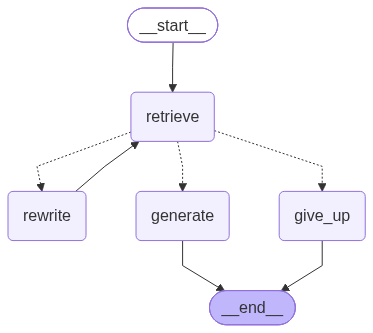

In [97]:
ask = StateGraph(AskState)
ask.add_node("retrieve", retrieve_node)
ask.add_node("rewrite", rewrite_node)
ask.add_node("generate", generate_node)
ask.add_node("give_up", give_up_node)

ask.add_edge(START, "retrieve")
ask.add_conditional_edges(
    "retrieve",
    after_retrieve,   # function that returns a string
    {                 # that string is looked up here
        "generate": "generate",
        "rewrite": "rewrite",
        "give_up": "give_up",
    },
)
ask.add_edge("rewrite", "retrieve")  # back to search — the arrow a chain cannot have
ask.add_edge("generate", END)
ask.add_edge("give_up", END)

ask_graph = ask.compile()
show_graph(ask_graph)


Run the two questions the chain failed. Watch the `[retrieve]` lines. You want
**two** retrieves on the synonym questions: miss, then hit.


In [95]:
def run_ask(query: str) -> None:
    print("=" * 56)
    print("Q:", query)
    result = ask_graph.invoke({
        "query": query, "context": "", "answer": "", "attempts": 0,
    })
    print("A:", result["answer"])
    print("   full board:", result)
    print()


run_ask("Can I get my money back?")    # chain said I don't know
run_ask("How fast do you ship?")       # chain said I don't know
run_ask("What's the refund policy?")   # already worked — one search, no loop


Q: Can I get my money back?
  [retrieve] try 1: 'Can I get my money back?'
  [rewrite]  'Can I get my money back?' → 'refund policy'
  [retrieve] try 2: 'refund policy'
  [generate] using 'Refunds take 5–7 business days to the original payment method.'
A: Based on policy: Refunds take 5–7 business days to the original payment method.
   full board: {'query': 'refund policy', 'context': 'Refunds take 5–7 business days to the original payment method.', 'answer': 'Based on policy: Refunds take 5–7 business days to the original payment method.', 'attempts': 2}

Q: How fast do you ship?
  [retrieve] try 1: 'How fast do you ship?'
  [rewrite]  'How fast do you ship?' → 'shipping policy'
  [retrieve] try 2: 'shipping policy'
  [generate] using 'Standard shipping is 2 business days inside the UAE.'
A: Based on policy: Standard shipping is 2 business days inside the UAE.
   full board: {'query': 'shipping policy', 'context': 'Standard shipping is 2 business days inside the UAE.', 'answer': 'Bas

**What to look at**

- `"Can I get my money back?"` — first `[retrieve]` misses, `[rewrite]` changes
  the query to `'refund policy'`, second `[retrieve]` hits, `[generate]` answers.
- The **full board** at the end still has `query`, `context`, `attempts`. That is
  the whiteboard. Print it after every graph you run.
- `attempts` is the safety cap. Without it, a question that never matches would
  loop forever.

Same `retrieve()` as Step 1. The only new thing is the arrow back.


---
# Step 4 of 10 — Don't overwrite the list (reducers)

**What we prove here (say this out loud):**

> When two nodes both write the same key, LangGraph **replaces** the old value
> unless you give it a **reducer** — a merge rule. Chat history must **append**.
> Without that rule, the second message erases the first, and the model "forgets"
> the user mid-turn.

We prove it twice, same picture, two kinds of list:

1. A dummy `notes` list — easy to read (`['hello']` vs `['hello', 'world']`)
2. Real chat `messages` — the thing an agent actually stores

A **reducer** is just that merge rule. `operator.add` means `old + new` for lists.
`add_messages` is the same idea, built for chat messages.


In [99]:
from typing import Annotated
from operator import add


class OverwriteState(TypedDict):
    notes: list[str]                 # no reducer → last write wins


class AppendState(TypedDict):
    notes: Annotated[list[str], add]  # new list is glued onto the old list


def write_hello(state: dict) -> dict:
    return {"notes": ["hello"]}


def write_world(state: dict) -> dict:
    return {"notes": ["world"]}


def run(state_cls, label: str) -> None:
    g = StateGraph(state_cls)
    g.add_node("a", write_hello)
    g.add_node("b", write_world)
    g.add_edge(START, "a")
    g.add_edge("a", "b")
    g.add_edge("b", END)
    print(f"{label:12} → {g.compile().invoke({'notes': []})['notes']}")


run(OverwriteState, "no reducer")
run(AppendState, "operator.add")


no reducer   → ['world']
operator.add → ['hello', 'world']


**What to look at (the `notes` proof)**

```
no reducer   → ['world']          # 'hello' was thrown away
operator.add → ['hello', 'world'] # both kept
```

The next cell is the same rule, but it has to *do some work* with the history —
not just print a list. Three nodes:

```
user → assistant → reporter
```

- `user` writes: `"Hi, my name is Noor."`
- `assistant` writes **only** the new reply (the same convention a real model
  node uses: `return {"messages": [one_new_message]}`)
- `reporter` looks at the board and answers: **"What is the user's name?"**

If the user line was overwritten, the reporter **cannot** answer. That is the
proof — a later step depends on the earlier message still being there.


In [104]:
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import MessagesState
from langgraph.graph.message import add_messages

# ---------------------------------------------------------------------------
# 1) The reducer by itself — no graph. This is "append" in one line.
# ---------------------------------------------------------------------------
already_on_board = [HumanMessage(content="Hi, my name is Noor.")]
what_the_node_returned = [AIMessage(content="Nice to meet you.")]

print("What the assistant node returned (the delta):")
print("   ", [m.content for m in what_the_node_returned])

print("add_messages(old, delta) — this is the merge rule:")
merged = add_messages(already_on_board, what_the_node_returned)
print("   ", [(m.type, m.content) for m in merged])
print("    ↑ both kept. A plain assignment would have kept only the delta.\n")


# ---------------------------------------------------------------------------
# 2) Same merge, inside a graph. A third node must READ the user's name.
#    If history was overwritten, the reporter fails. That is the proof.
# ---------------------------------------------------------------------------
class PlainChat(TypedDict):
    messages: list   # no reducer — last write wipes the board


def user_node(state: dict) -> dict:
    # A real chat app writes the human turn like this: only the NEW message.
    return {"messages": [HumanMessage(content="Hi, my name is Noor.")]}


def assistant_node(state: dict) -> dict:
    # A real model node does the same: return ONLY the model's new reply.
    # It does NOT return the full history. The reducer is supposed to append.
    return {"messages": [AIMessage(content="Nice to meet you.")]}


def reporter_node(state: dict) -> dict:
    """This node is the test. It has to answer from the board, not from memory."""
    board = state["messages"]
    print(f"  [reporter] messages on the board: {len(board)}")
    for m in board:
        print(f"              {m.type:8} {m.content}")

    user_lines = [m.content for m in board if getattr(m, "type", None) == "human"]
    if user_lines:
        print(f"  [reporter] user's name is still readable → {user_lines[0]!r}")
    else:
        print("  [reporter] FAILED — no human message on the board.")
        print("              The assistant's reply overwrote the user turn.")
    return {}


def run_chat(state_cls, title: str) -> None:
    print("=" * 60)
    print(title)
    g = StateGraph(state_cls)
    g.add_node("user", user_node)
    g.add_node("assistant", assistant_node)
    g.add_node("reporter", reporter_node)
    g.add_edge(START, "user")
    g.add_edge("user", "assistant")
    g.add_edge("assistant", "reporter")
    g.add_edge("reporter", END)
    g.compile().invoke({"messages": []})


run_chat(PlainChat, "A) Plain list — no reducer")
run_chat(MessagesState, "B) MessagesState — add_messages reducer")


What the assistant node returned (the delta):
    ['Nice to meet you.']
add_messages(old, delta) — this is the merge rule:
    [('human', 'Hi, my name is Noor.'), ('ai', 'Nice to meet you.')]
    ↑ both kept. A plain assignment would have kept only the delta.

A) Plain list — no reducer
  [reporter] messages on the board: 1
              ai       Nice to meet you.
  [reporter] FAILED — no human message on the board.
              The assistant's reply overwrote the user turn.
B) MessagesState — add_messages reducer
  [reporter] messages on the board: 2
              human    Hi, my name is Noor.
              ai       Nice to meet you.
  [reporter] user's name is still readable → 'Hi, my name is Noor.'


**What to look at (this is the proof)**

Part 1 — `add_messages(old, delta)` printed **two** messages even though the
node only returned **one**. That function *is* the append rule.

Part 2 — the `reporter` node never saw the original Python variables. It only
reads `state["messages"]`.

```
A) Plain list — no reducer
  [reporter] messages on the board: 1
              ai       Nice to meet you.
  [reporter] FAILED — no human message on the board.

B) MessagesState — add_messages reducer
  [reporter] messages on the board: 2
              human    Hi, my name is Noor.
              ai       Nice to meet you.
  [reporter] user's name is still readable → 'Hi, my name is Noor.'
```

**What this means:** every model node in Step 8 will `return {"messages": [one
new AIMessage]}`. That only works if the whiteboard **appends**. `MessagesState`
is that whiteboard. We are not teaching a new feature — we are showing why a
plain `list` would make an agent forget the user after one reply.


---
# Step 5 of 10 — Same graph, now with a model

**In one sentence:** calling an LLM does not change State / Node / Edge. It is
still a function that reads the board and returns a small update.

Two nodes: pick a topic, then write a one-line joke. This is the first cell that
needs `OPENAI_API_KEY`.


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	pick_topic(pick_topic)
	write_joke(write_joke)
	__end__([<p>__end__</p>]):::last
	__start__ --> pick_topic;
	pick_topic --> write_joke;
	write_joke --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



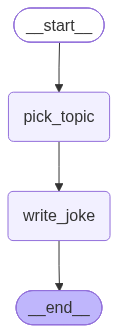

Final board: {'topic': 'Langraph', 'joke': 'Why did Langraph bring a ladder to the meeting? Because it wanted to elevate the conversation!'}


In [107]:
class JokeState(TypedDict):
    topic: str
    joke: str


def pick_topic(state: JokeState) -> dict:
    return {"topic": state["topic"]}


def write_joke(state: JokeState) -> dict:
    joke = llm.invoke(f"Write a one-line joke about {state['topic']}.").content
    return {"joke": joke}


joke = StateGraph(JokeState)
joke.add_node("pick_topic", pick_topic)
joke.add_node("write_joke", write_joke)
joke.add_edge(START, "pick_topic")
joke.add_edge("pick_topic", "write_joke")
joke.add_edge("write_joke", END)

joke_graph = joke.compile()
show_graph(joke_graph)

print("Final board:", joke_graph.invoke({"topic": "Langraph", "joke": ""}))


**What to look at**

The picture looks like Step 2. The only difference is `write_joke` calls `llm`.
Compare this to Step 2's `tiny_graph`. Same shape. That is the point.


---
# Step 6 of 10 — Branch (easy vs hard)

**In one sentence:** after a classify step, the next box depends on what was
written on the board.

```
START → classify ── SIMPLE  → short_answer  → END
                 └── COMPLEX → detailed_answer → END
```

Four questions go through the **same** graph. Two should print `[short_answer]`,
two should print `[detailed_answer]`. If every line says SIMPLE, the classifier
prompt is too weak — that is a routing bug, not a graph bug.


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	classify(classify)
	short_answer(short_answer)
	detailed_answer(detailed_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> classify;
	classify -.-> detailed_answer;
	classify -.-> short_answer;
	detailed_answer --> __end__;
	short_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



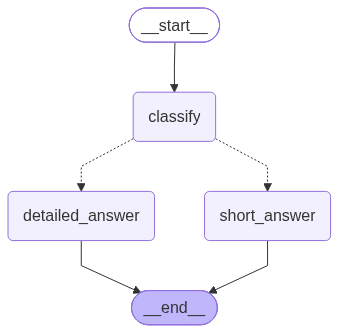

  [classify] SIMPLE
  [short_answer]
[SIMPLE] What's 2 + 2?
  2 + 2 equals 4. 

  [classify] SIMPLE
  [short_answer]
[SIMPLE] What is the capital of France?
  The capital of France is Paris. 

  [classify] COMPLEX
  [detailed_answer]
[COMPLEX] Compare self-attention to recurrence and recommend which to use for a 10,000-token document. Give one concrete tradeoff.
  Self-attention and recurrence are two fundamental mechanisms used in natural language processing (NLP) models, particularly in the context of sequence modeling. Each has its strengths and weaknesses, and the choice between them can significantly impact the performance of a model, 

  [classify] COMPLEX
  [detailed_answer]
[COMPLEX] Design a retry policy for a failed payment API: when to retry, when to give up, and what to tell the customer. Include an example.
  Designing a retry policy for a failed payment API is crucial for ensuring a smooth user experience while also managing system resources effectively. A well-structured

In [108]:
class RouteState(TypedDict):
    question: str
    complexity: str   # filled by classify: "SIMPLE" or "COMPLEX"
    answer: str


def classify(state: RouteState) -> dict:
    # Few-shot labels so "explain why X" is not treated as SIMPLE.
    raw = llm.invoke(
        "Classify the question as SIMPLE or COMPLEX.\n"
        "SIMPLE  = a fact, a number, or one short sentence is enough.\n"
        "         e.g. What is 2+2? / What is the capital of France?\n"
        "COMPLEX = needs a comparison, a tradeoff, or a worked example.\n"
        "         e.g. Compare two designs and recommend one.\n"
        f"Question: {state['question']}\n"
        "Reply with exactly one word: SIMPLE or COMPLEX"
    ).content.strip().upper()
    label = "COMPLEX" if "COMPLEX" in raw else "SIMPLE"
    print(f"  [classify] {label}")
    return {"complexity": label}


def short_answer(state: RouteState) -> dict:
    print("  [short_answer]")
    return {"answer": llm.invoke("One sentence: " + state["question"]).content.strip()}


def detailed_answer(state: RouteState) -> dict:
    print("  [detailed_answer]")
    return {
        "answer": llm.invoke(
            "Answer thoroughly, with one example: " + state["question"]
        ).content.strip()
    }


def pick_path(state: RouteState) -> str:
    return "detailed_answer" if state["complexity"] == "COMPLEX" else "short_answer"


router = StateGraph(RouteState)
router.add_node("classify", classify)
router.add_node("short_answer", short_answer)
router.add_node("detailed_answer", detailed_answer)
router.add_edge(START, "classify")
router.add_conditional_edges(
    "classify", pick_path,
    {"short_answer": "short_answer", "detailed_answer": "detailed_answer"},
)
router.add_edge("short_answer", END)
router.add_edge("detailed_answer", END)
router_graph = router.compile()
show_graph(router_graph)

QUESTIONS = [
    "What's 2 + 2?",                                          # SIMPLE
    "What is the capital of France?",                          # SIMPLE
    "Compare self-attention to recurrence and recommend which "
    "to use for a 10,000-token document. Give one concrete tradeoff.",  # COMPLEX
    "Design a retry policy for a failed payment API: when to retry, "
    "when to give up, and what to tell the customer. Include an example.",  # COMPLEX
]

for q in QUESTIONS:
    out = router_graph.invoke({"question": q, "complexity": "", "answer": ""})
    print(f"[{out['complexity']}] {q}")
    print(" ", out["answer"][:280], "\n")


**What to look at**

| Question | You should see |
|---|---|
| 2 + 2 / capital of France | `[classify] SIMPLE` then `[short_answer]` |
| self-attention tradeoff / payment retry policy | `[classify] COMPLEX` then `[detailed_answer]` |

If the last two still say SIMPLE, the model ignored the few-shot rule — say so
out loud. The graph only follows the **string** `pick_path` returned. It does
not know whether that string was a good classification.

`pick_path` did not call `short_answer` or `detailed_answer`. It returned a
name. LangGraph followed that arrow. Same trick as `after_retrieve` in Step 3.


**Where this shows up in real products**

The graph you just ran is not a toy classifier. It is the cheapest production
pattern in agents and RAG: **look at the request, then pick an expensive path
only when you need it.**

A live app cannot send every message through the full pipeline. "What's my
order status?" should be one lookup. "Compare three plans and tell me which
to buy, given last quarter's usage" should retrieve, rewrite, maybe call
tools, maybe ask a human. Same entry point. Different arrows.

| Product | SIMPLE path | COMPLEX path |
|---|---|---|
| **Customer support** | FAQ / order-status lookup, one retrieve, cheap model | Multi-step agent: search tickets + refund tool + escalate |
| **RAG chatbot** | One hybrid search, answer from top-3 chunks | Rewrite the query, retrieve again, rerank, grade the docs (that is this module's capstone) |
| **Cost router** | `gpt-4o-mini` or a local 8B — fast, cheap | `gpt-4o` / a 70B only when the label is COMPLEX |
| **Tool-using agent** | Greetings and "what can you do?" → no tools | "Book a slot on Tuesday and email me" → calendar + mail tools |
| **Code assistant** | Rename a variable, explain one function | Multi-file refactor: search repo → edit → run tests → loop |
| **Risk / compliance** | Low-risk reply goes straight out | High-risk (refund, delete, transfer) → `interrupt()` for a human (next notebook) |

**Why a graph, not an `if` in Python?** You *can* write `if complexity == "COMPLEX":`.
The graph earns its keep when the next step is not just "call a different
function" but **loop, pause, or remember**: retry retrieval, wait for a human,
or resume tomorrow with the same `thread_id`. The classify → branch you just
built is the first arrow of that system.

**What to tell a hiring manager:** "We classify the turn, then route. Simple
turns skip tools and use a small model. Complex turns enter the agent / RAG
loop. That cut our token bill and kept p95 latency down without dumbing down
the hard questions."


---
# Step 7 of 10 — Loop until it is good enough

**In one sentence:** branching picks a different next box. A **cycle** points
at a box you already ran.

```
START → writer → critic ── score ≥ 7 (or 2 edits) → END
                    └── score < 7 and edits < 2  → reviser → critic
```

This is Step 3's idea (search again) with an LLM in the boxes. Watch `[critic]`
in the printout. If it appears twice, the loop really ran.


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	writer(writer)
	critic(critic)
	reviser(reviser)
	__end__([<p>__end__</p>]):::last
	__start__ --> writer;
	critic -. &nbsp;publish&nbsp; .-> __end__;
	critic -. &nbsp;revise&nbsp; .-> reviser;
	reviser --> critic;
	writer --> critic;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



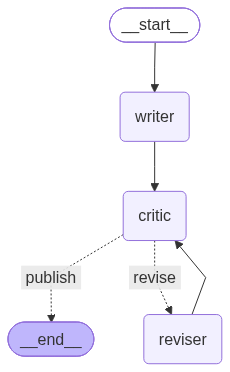


Running...

  [writer]
  [critic] score=7  feedback='Add more detail about specific use cases or examples where langgraphs outperform langchains.'
  → revise
  [reviser] edit 1
  [critic] score=7  feedback='Add more detail'
  → revise
  [reviser] edit 2
  [critic] score=7  feedback='Add more detail about specific use cases or examples to illustrate the advantages of langgraphs over langchains.'
  → publish

score: 7  edits: 2
A langgraph is designed to dynamically adjust its execution flow based on real-time feedback and errors encountered during processing, allowing it to retry and refine its outputs effectively. For example, in natural language processing tasks like sentiment analysis, a langgraph can reassess its previous interpretations by incorporating user corrections or additional contextual information. This iterative process enables the langgraph to enhance its accuracy and relevance over time, as it learns from past interactions and adapts to the nuances of human language.



In [123]:
import json, re
from langsmith import traceable
from langsmith.wrappers import wrap_openai

class WritingState(TypedDict):
    topic: str
    draft: str
    feedback: str
    score: int
    revision_count: int

@traceable
def writer_node(state: WritingState) -> dict:
    print("  [writer]")
    draft = llm.invoke(
        f"Write 3 short sentences about: {state['topic']}"
    ).content
    return {"draft": draft, "revision_count": state.get("revision_count", 0)}

@traceable
def critic_node(state: WritingState) -> dict:
    raw = llm.invoke(
        "Rate 1-10 and give one suggestion.\n"
        f"Text: {state['draft']}\n"
        'JSON only: {"score": 7, "feedback": "Add more detail"}'
    ).content
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    data = json.loads(match.group()) if match else {"score": 5, "feedback": "Improve"}
    print(f"  [critic] score={data.get('score')}  feedback={data.get('feedback')!r}")
    return {"score": int(data.get("score", 5)), "feedback": str(data.get("feedback", "Improve"))}

@traceable
def reviser_node(state: WritingState) -> dict:
    print(f"  [reviser] edit {state['revision_count'] + 1}")
    draft = llm.invoke(
        f"Improve this.\nOriginal: {state['draft']}\nFeedback: {state['feedback']}\n"
        "Improved version only:"
    ).content
    return {"draft": draft, "revision_count": state["revision_count"] + 1}

@traceable
def should_revise(state: WritingState) -> str:
    if state["score"] >= 8 or state["revision_count"] >= 2:
        print("  → publish")
        return "publish"
    print("  → revise")
    return "revise"


write = StateGraph(WritingState)
write.add_node("writer", writer_node)
write.add_node("critic", critic_node)
write.add_node("reviser", reviser_node)
write.add_edge(START, "writer")
write.add_edge("writer", "critic")
write.add_conditional_edges("critic", should_revise, {"publish": END, "revise": "reviser"})
write.add_edge("reviser", "critic")
write_graph = write.compile()
show_graph(write_graph)

print("\nRunning...\n")
written = write_graph.invoke({
    "topic": "why a langgraph can retry and a langchain cannot",
    "draft": "", "feedback": "", "score": 0, "revision_count": 0,
})
print("\nscore:", written["score"], " edits:", written["revision_count"])
print(written["draft"])


**What to look at**

- If `[critic]` printed more than once, the cycle ran.
- `revision_count` on the final board is how many times we went around — that
  number is more useful than whether the paragraph "looks nice."


---
# Step 8 of 10 — An agent is a graph with tools

**In one sentence:** an agent is not a special object. It is:

```
START → agent ── model asked for a tool → tools → agent
              └── model is done (no tool)  → END
```

Four pieces, always:

1. **Tools** — ordinary Python functions the model is allowed to call
2. **Model node** — sends the message list to the LLM (`bind_tools` so it *can* call them)
3. **Tools node** — actually runs those functions (`ToolNode`)
4. **A loop** — `tools_condition`: "did the model request a tool? go to tools; else stop"

We build it by hand, then show the one-liner that packages the same picture.


## 8a — Define two fake tools

The **docstring** is what the model reads. If it is vague, the model guesses
the arguments wrong.


In [113]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def get_weather(city: str) -> str:
    """Return the current weather for a city (simulated, not live)."""
    fake = {"dubai": "38C, clear", "london": "16C, light rain", "chennai": "31C, humid"}
    return fake.get(city.lower(), f"{city}: 27C, partly cloudy")


@tool
def word_count(text: str) -> int:
    """Count the words in a string."""
    return len(text.split())


tools = [get_weather, word_count]
llm_with_tools = llm.bind_tools(tools)  # attach the schemas to the model
print("Tools:", [t.name for t in tools])


Tools: ['get_weather', 'word_count']


## 8b — Wire the four pieces

`MessagesState` is the whiteboard from Step 4: a `messages` list that **appends**.


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



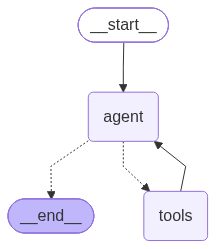

In [114]:
def call_model(state: MessagesState) -> dict:
    # Returning a one-item list APPENDS that message, because of add_messages.
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


agent = StateGraph(MessagesState)
agent.add_node("agent", call_model)
agent.add_node("tools", ToolNode(tools))
agent.add_edge(START, "agent")
agent.add_conditional_edges("agent", tools_condition)  # → "tools" or END
agent.add_edge("tools", "agent")                       # observation goes back to the model

hand_rolled = agent.compile()
show_graph(hand_rolled)


## 8c — Watch the messages, one by one

We print **every new message**, not just the last. One `tools` step can add
*two* ToolMessages (weather and word count) at once. Printing only `[-1]`
would hide the first.


In [116]:
print("Each block is one node finishing.\n")
prev = 0
for chunk in hand_rolled.stream(
    {"messages": [("user", "What's the weather in Dubai, and how many words are in "
                            "'stateful agent graphs beat linear chains'?")]},
    stream_mode="values",
):
    for msg in chunk["messages"][prev:]:
        msg.pretty_print()
        print()
    prev = len(chunk["messages"])


Each block is one node finishing.

================================ Human Message =================================

What's the weather in Dubai, and how many words are in 'stateful agent graphs beat linear chains'?

================================== Ai Message ==================================
Tool Calls:
  get_weather (call_61pKYOeX2RZApuHDSRC9jOMY)
 Call ID: call_61pKYOeX2RZApuHDSRC9jOMY
  Args:
    city: Dubai
  word_count (call_a4KAIJ0OVMUkqMV1QXy1zzab)
 Call ID: call_a4KAIJ0OVMUkqMV1QXy1zzab
  Args:
    text: stateful agent graphs beat linear chains

================================= Tool Message =================================
Name: get_weather

38C, clear

================================= Tool Message =================================
Name: word_count

6

================================== Ai Message ==================================

The weather in Dubai is 38°C and clear. The phrase "stateful agent graphs beat linear chains" contains 6 words.



**What to look at** (in order)

1. `HumanMessage` — your question
2. `AIMessage` with `tool_calls=[get_weather, word_count]` — the model *asked*, it did not answer yet
3. Two `ToolMessage`s — the tools node ran both functions
4. `AIMessage` with normal text, no `tool_calls` — the model is done → END

If you remember one sentence from Step 8: **an agent is a model box, a tools
box, and an arrow that loops until the model stops asking.**


## 8d — The same picture, packaged

`create_agent` (LangChain 1.0) builds that graph for you.
`create_react_agent` is the older name. Both sit on the same four pieces.


In [118]:
try:
    from langchain.agents import create_agent
    fast_agent = create_agent(model="gpt-4o-mini", tools=tools)
    print("Using langchain.agents.create_agent")
except ImportError:
    from langgraph.prebuilt import create_react_agent
    fast_agent = create_react_agent(llm, tools)
    print("Using langgraph.prebuilt.create_react_agent (older helper)")

result = fast_agent.invoke({"messages": [("user", "What's the weather in London?")]})
result["messages"][-1].pretty_print()

result = fast_agent.invoke({"messages": [("user", "What's the weather in Dubai, and how many words are in 'stateful agent graphs beat linear chains'?")]})
result["messages"][-1].pretty_print()


Using langchain.agents.create_agent
================================== Ai Message ==================================

The weather in London is 16°C with light rain.
================================== Ai Message ==================================

The weather in Dubai is 38°C and clear. The phrase "stateful agent graphs beat linear chains" contains 6 words.


---
# Step 9 of 10 — Memory that survives the next question

**In one sentence:** a **checkpointer** snapshots the whiteboard after every
node, keyed by a `thread_id`. Same graph, no changes to the nodes.

Two things you may already have seen in the RAG module, kept separate on purpose:

| Earlier | What it was |
|---|---|
| The RAG chatbot's `self.history` | A Python list on the object. Gone when the process stops. |
| `create_agent(..., checkpointer=...)` | This same idea, packaged as a helper. |

Today we put a checkpointer on the **hand-built** graph from Step 8, so you can
see that memory is a `compile()` option — not extra code inside `call_model`.


In [120]:
from langgraph.checkpoint.memory import InMemorySaver

memory_agent = agent.compile(checkpointer=InMemorySaver())

# Same student, two questions.
student_1 = {"configurable": {"thread_id": "student-1"}}
memory_agent.invoke({"messages": [("user", "My name is Noor. Remember that.")]}, student_1)
follow = memory_agent.invoke({"messages": [("user", "What's my name?")]}, student_1)
print("Same thread :", follow["messages"][-1].content)

# Different student, same question.
student_2 = {"configurable": {"thread_id": "student-2"}}
other = memory_agent.invoke({"messages": [("user", "What's my name?")]}, student_2)
print("Other thread:", other["messages"][-1].content)


Same thread : You mentioned that your name is Noor. How can I assist you today, Noor?
Other thread: I don't have access to your personal information, so I don't know your name. If you'd like to share it, feel free!


**What to look at**

- Same `thread_id` → it should say **Noor**.
- Other `thread_id` → it should **not** know the name.

`InMemorySaver` lives only in this kernel. Restart the kernel and it is gone.
`SqliteSaver` / `PostgresSaver` use the same `checkpointer=` slot — swap the
class, leave the graph alone.


---
# Step 10 of 10 — Watch it run

Three cameras on the same graph:

| Mode | What you get | Use when |
|---|---|---|
| `"values"` | Full board after each node | "What does the whiteboard look like now?" (you used this in Step 8) |
| `"updates"` | Only what that node changed | A live trace in a UI |
| `"messages"` | Tokens as the model types | A chat box |

The updates demo asks a **tool** question so you should see
`[agent] → [tools] → [agent]`, not a single `[agent]` line.


In [124]:
print("--- updates: one line per node ---")
for update in memory_agent.stream(
    {"messages": [("user", "What's the weather in Dubai?")]},
    student_1,
    stream_mode="updates",
):
    for node_name, node_output in update.items():
        shown = {k: ("<messages>" if k == "messages" else v) for k, v in node_output.items()}
        print(f"  [{node_name}] {shown}")

print("\n--- messages: tokens as they arrive ---")
for token, meta in memory_agent.stream(
    {"messages": [("user", "Name one use of a multi-agent supervisor, in five words.")]},
    student_1,
    stream_mode="messages",
):
    if getattr(token, "content", None):
        print(token.content, end="", flush=True)
print()


--- updates: one line per node ---
  [agent] {'messages': '<messages>'}
  [tools] {'messages': '<messages>'}
  [agent] {'messages': '<messages>'}

--- messages: tokens as they arrive ---
Coordinating tasks among multiple agents.


**What to look at**

- Updates: you want three lines, `agent`, then `tools`, then `agent` again.
- Tokens: words appearing one after another, like a chat UI.

You now have the whole toolkit: state, nodes, edges, loops, tools, memory,
streaming. Everything below is practice. It is optional.


---
# Your turn (optional) — build a small retry loop

If this is your first pass, **stop here** and come back later. The next notebook
does not depend on these TODOs.

Build:

```
START → research → quality_check ── good        → END
                        └── needs_more → research
```

**Do not type `___`.** In Jupyter, `_` `__` `___` already mean "the last three
outputs." Use `TODO("hint")`. Leave one in and you get a clear error instead of
a mystery crash.

Run All will **not** get stuck here. Fill the TODOs when you are ready, then
re-run those cells.


In [125]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


def TODO(hint: str):
    raise NotImplementedError(
        f"Still a blank: {hint}\nReplace TODO('...') with the real value and re-run."
    )


# Given. Read the four keys — you will use them in the nodes below.
class ResearchState(TypedDict):
    question: str
    answer: str
    quality: str    # "good" or "needs_more"
    attempts: int


print("State keys:", list(ResearchState.__annotations__))


State keys: ['question', 'answer', 'quality', 'attempts']


**TODO — research node.** Replace each `TODO(...)`.

- First try: ask the question.
- Later tries: ask again, and demand more detail plus an example.


In [126]:
def research_node(state: ResearchState) -> dict:
    print(f"  [research] try {state['attempts'] + 1}")
    if state["attempts"] > 0:
        prompt = TODO("f-string: ask state['question'] again, with more detail + an example")
    else:
        prompt = TODO("f-string: ask state['question']")
    response = llm.invoke(TODO("the prompt variable"))
    return {
        "answer": TODO("response.content"),
        "attempts": state["attempts"] + 1,
    }


print("research_node is defined")


research_node is defined


**TODO — quality node.** If `attempts` is already 2, accept the answer
(`quality="good"`) so the loop cannot run forever.


In [127]:
def quality_check_node(state: ResearchState) -> dict:
    answer = state.get("answer") or ""
    print(f"  [quality] {len(answer)} chars")
    if state["attempts"] >= TODO("integer 2"):
        return {"quality": "good"}
    verdict = llm.invoke(
        "Reply with one word, good or needs_more:\n\n" + answer
    ).content.strip().lower()
    if "good" in verdict and "needs_more" not in verdict:
        quality = TODO("'good'")
    else:
        quality = TODO("'needs_more'")
    print("   ", quality)
    return {"quality": quality}


print("quality_check_node is defined")


quality_check_node is defined


**TODO — wire the picture.** Same pattern as Step 3 and Step 7.


In [128]:
def route_quality(state: ResearchState) -> str:
    if state["quality"] == TODO("'good'"):
        return "done"
    return "retry"


try:
    rb = StateGraph(ResearchState)
    rb.add_node("research", TODO("research_node"))
    rb.add_node("quality_check", TODO("quality_check_node"))
    rb.add_edge(START, TODO("'research'"))
    rb.add_edge("research", TODO("'quality_check'"))
    rb.add_conditional_edges(
        TODO("'quality_check'"),
        route_quality,
        {"done": END, "retry": TODO("'research'")},
    )
    research_app = rb.compile()
    print("Compiled. Run the next cell.")
except NotImplementedError as e:
    print("Not compiled yet — that's OK. Fill the TODOs and re-run this cell.")
    print(e)


Not compiled yet — that's OK. Fill the TODOs and re-run this cell.
Still a blank: research_node
Replace TODO('...') with the real value and re-run.


In [129]:
if "research_app" not in globals():
    print("Skip — finish the TODOs above first.")
else:
    out = research_app.invoke({
        "question": "What is a LangGraph reducer, in one short paragraph with an example?",
        "answer": "", "quality": "", "attempts": 0,
    })
    print("attempts:", out["attempts"], " quality:", out["quality"])
    print(out["answer"])


Skip — finish the TODOs above first.


**Hints** (read after you have tried): retry prompt includes "more detail and an
example"; `llm.invoke(prompt)`; `response.content`; cap `2`; labels `"good"` /
`"needs_more"`; `add_node` wants the **function**, not a string; start at
`"research"`; retry goes back to `"research"`.


---
# Optional experiments

Skip this whole block if you are done for the day. They reuse `write_graph` and
`WritingState` from **Step 7** (the writer → critic loop).


### A — Change the passing score

Same topic, three bars: 5, 7, 9. A higher bar should cause more edits, until the
cap of 2 stops it. This is the expensive cell (three full writing runs). Set
`RUN_EXPENSIVE = False` in Setup to skip it.


In [130]:
if not RUN_EXPENSIVE:
    print("Skipped. Set RUN_EXPENSIVE = True in Setup to run Experiment A.")
else:

    def build_writing_app(threshold: int):
        def routing(state: WritingState) -> str:
            if state["score"] >= threshold or state["revision_count"] >= 2:
                return "publish"
            return "revise"

        b = StateGraph(WritingState)
        b.add_node("writer", writer_node)
        b.add_node("critic", critic_node)
        b.add_node("reviser", reviser_node)
        b.add_edge(START, "writer")
        b.add_edge("writer", "critic")
        b.add_conditional_edges("critic", routing, {"publish": END, "revise": "reviser"})
        b.add_edge("reviser", "critic")
        return b.compile()

    topic = "the benefit of writing state down before calling an LLM"
    for threshold in [5, 7, 9]:
        print(f"\n===== threshold {threshold} =====")
        out = build_writing_app(threshold).invoke({
            "topic": topic, "draft": "", "feedback": "", "score": 0, "revision_count": 0,
        })
        print(f"score={out['score']}  edits={out['revision_count']}")



===== threshold 5 =====
  [writer]
  [critic] score=7  feedback='Add more detail about how documenting the state can specifically improve the interaction with the LLM.'
score=7  edits=0

===== threshold 7 =====
  [writer]
  [critic] score=7  feedback='Add more detail about how documenting the state can specifically enhance the interaction with the LLM.'
score=7  edits=0

===== threshold 9 =====
  [writer]
  [critic] score=7  feedback='Add more detail about how documenting the state can specifically improve the interaction with the LLM.'
  [reviser] edit 1
  [critic] score=7  feedback='Add more detail on specific methods for documenting the state and examples of how it improves interactions.'
  [reviser] edit 2
  [critic] score=8  feedback='Consider including examples of specific documentation methods or tools that can be used to enhance the process.'
score=8  edits=2


### B — Add a box without rewriting the others

After the critic publishes, send the draft through a `formatter` that wraps HTML.
`"publish"` now points at `"formatter"`, not `END`. Writer / critic / reviser
stay untouched.

This still uses Step 7's rule (publish at score ≥ 7). Only the new arrow is the
lesson.


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	writer(writer)
	critic(critic)
	reviser(reviser)
	formatter(formatter)
	__end__([<p>__end__</p>]):::last
	__start__ --> writer;
	critic -. &nbsp;publish&nbsp; .-> formatter;
	critic -. &nbsp;revise&nbsp; .-> reviser;
	reviser --> critic;
	writer --> critic;
	formatter --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



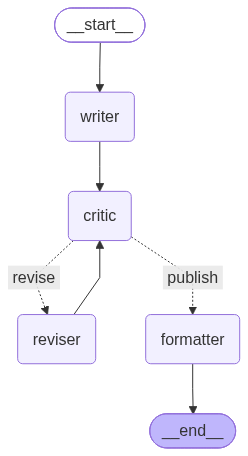

  [writer]
  [critic] score=7  feedback='Add more detail about the specific advantages and disadvantages of each option.'
  → revise
  [reviser] edit 1
  [critic] score=7  feedback='Add more detail about the advantages and disadvantages of each tool, perhaps including specific scenarios where one might be preferred over the other.'
  → revise
  [reviser] edit 2
  [critic] score=7  feedback='Add more detail on the specific scenarios where each tool excels and consider including examples of alternative tools that could complement or enhance the brainstorming process.'
  → publish
  [formatter]
<article><h1>Whiteboards Vs Notepads</h1><p>Score 7/10 · edits 2</p><div>Whiteboards offer a versatile and reusable surface that significantly enhances brainstorming and collaboration, making them particularly effective in group settings. Their expansive, visible area allows for dynamic visual displays, enabling teams to map out ideas, create diagrams, and engage in interactive discussions. For ins

In [131]:
def formatter_node(state: WritingState) -> dict:
    print("  [formatter]")
    html = (
        f"<article><h1>{state['topic'].title()}</h1>"
        f"<p>Score {state['score']}/10 · edits {state['revision_count']}</p>"
        f"<div>{state['draft']}</div></article>"
    )
    return {"draft": html}


fmt = StateGraph(WritingState)
fmt.add_node("writer", writer_node)
fmt.add_node("critic", critic_node)
fmt.add_node("reviser", reviser_node)
fmt.add_node("formatter", formatter_node)
fmt.add_edge(START, "writer")
fmt.add_edge("writer", "critic")
fmt.add_conditional_edges(
    "critic", should_revise, {"publish": "formatter", "revise": "reviser"}
)
fmt.add_edge("reviser", "critic")
fmt.add_edge("formatter", END)
fmt_app = fmt.compile()
show_graph(fmt_app)
print(fmt_app.invoke({
    "topic": "whiteboards vs notepads",
    "draft": "", "feedback": "", "score": 0, "revision_count": 0,
})["draft"])


### C — Count how many times each box ran

If `reviser` is greater than 0, you watched a cycle happen.


In [132]:
print("Each line is one node finishing.\n")
counts = {}
for event in write_graph.stream({
    "topic": "why a max-iterations cap belongs on the step that needs it",
    "draft": "", "feedback": "", "score": 0, "revision_count": 0,
}):
    for name, output in event.items():
        counts[name] = counts.get(name, 0) + 1
        extra = f" score={output['score']}" if "score" in output else ""
        print(f"  [{counts[name]}x] {name}{extra}")
print("\nCounts:", counts)


Each line is one node finishing.

  [writer]
  [1x] writer
  [critic] score=7  feedback='Add more detail about how max-iterations can impact algorithm performance in different scenarios.'
  → revise
  [1x] critic score=7
  [reviser] edit 1
  [1x] reviser
  [critic] score=7  feedback='Add more detail'
  → revise
  [2x] critic score=7
  [reviser] edit 2
  [2x] reviser
  [critic] score=7  feedback='Add more detail on specific algorithms or scenarios where a max-iterations cap has proven particularly beneficial.'
  → publish
  [3x] critic score=7

Counts: {'writer': 1, 'critic': 3, 'reviser': 2}


---
# Optional challenge — a debate (three boxes, no loop)

```
START → pro → con → judge → END
```

Whiteboard keys: `topic`, `pro_argument`, `con_argument`, `verdict`
(`"pro"` / `"con"` / `"draw"`), `reasoning`.

Prompts you can steal:

- pro: `Argue FOR: {topic}. Give 3 points.`
- con: `Argue AGAINST: {topic}. Attack: {pro_argument}`
- judge: both arguments in; reply `Verdict: pro|con|draw` plus why

Try topic: `"Python is a better teaching language for AI than JavaScript"`.

Harder extra: a `moderator` box between pro and con that tells con which one
point to attack. Still a straight line — but three specialists, one board.
That is the seed of the next notebook.


In [133]:
# Your debate graph goes here.
print("Replace this cell: DebateState, three nodes, add_edge from START to END, invoke.")


Replace this cell: DebateState, three nodes, add_edge from START to END, invoke.


---
# What you should be able to explain out loud

If you can answer these without looking, you are done.

1. What is state? What is a node? What is an edge?
2. Why did "Can I get my money back?" fail in a chain and succeed in a graph?
3. What does a reducer do? What goes wrong without one on a messages list?
4. What are the four pieces of a tool-calling agent?
5. Why does `compile(checkpointer=...)` change memory without changing the nodes?

| Straight line | Graph |
|---|---|
| Fixed order | Order can include going **back** |
| Cannot branch on the model's last output | A router returns the next box's name |
| Last write wipes a list | A reducer says how to merge |
| History as a list on one object | Checkpointer + `thread_id` |
| One blob of output at the end | Stream per node or per token |
| "Agent" sounds like magic | Model box + tools box + a loop |

**Habit:** after `compile()`, call `show_graph()`. After `invoke()`, print the
full board.

**Next notebook:** `02_human_in_the_loop.ipynb` — pause the
graph for a human (`interrupt()`). You type yes or no. Then notebook 03 puts
that pause after a RAG retry loop.
